# DQN ablation sweep — full analysis

Fetches **every** saved run in `../runs/` and compares the overnight sweep side by side: the
ablation grid, seed-variance ranking, capacity/lr curves, learning curves, and the two dynamics
analyses the instrumentation enables — **Q1** (was the over-valued action over- or under-*tested*?)
and **Q2** (how did the Q-values evolve?). Run top-to-bottom in the Phase-3 venv.

Robust to mixed records: older runs lack `sample_counts`/`probe_q`; those cells say so and use an
instrumented run instead.

In [1]:
import json, glob, os
from pathlib import Path
from collections import defaultdict
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUNS = Path("..") / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 120)
print("records on disk:", len(list(RUNS.glob("*/record.json"))))

records on disk: 35


## 1. Load every run

In [2]:
def load_runs():
    out = []
    for f in sorted(RUNS.glob("*/record.json")):
        try:
            r = json.load(open(f))
        except Exception as e:
            print("skip", f, e); continue
        r["_id"] = f.parent.name
        out.append(r)
    return out

RECORDS = load_runs()
is_dqn = lambda r: r.get("method") == "dqn"
DQN = [r for r in RECORDS if is_dqn(r)]
print(f"{len(RECORDS)} total | {len(DQN)} DQN | {len(RECORDS)-len(DQN)} tabular")

35 total | 27 DQN | 8 tabular


## 2. Master table — every DQN run, every knob

In [3]:
def row(r):
    c, d, m = r["config"], r["diff"], r["metrics"]
    gen = [x for x in d["cells"] if x["category"] == "genuine_disagreement"]
    over  = sum(1 for x in gen if x["agent_action"]=="double" and x["basic_action"]!="double")
    under = sum(1 for x in gen if x["basic_action"]=="double" and x["agent_action"]!="double")
    return {
        "id": r["_id"][-7:], "enc": c.get("encoding"), "double": c.get("double_dqn"),
        "hidden": str(c.get("hidden")), "lr": c.get("lr"), "train_ev": c.get("train_every"),
        "tgt_sync": c.get("target_sync_every"), "ES": c.get("exploring_starts"), "seed": c.get("seed"),
        "eps": c.get("num_episodes"), "agree%": round(d["agreement_unweighted"]*100, 1),
        "edge%": round(m["agent"]["edge"]*100, 3), "genuine": len(gen),
        "over_dbl": over, "under_dbl": under, "instr": bool(r.get("sample_counts")),
    }

tbl = pd.DataFrame([row(r) for r in DQN])
tbl = tbl.sort_values(["ES","enc","double","hidden","lr","seed"]).reset_index(drop=True)
tbl

,id,enc,double,hidden,lr,train_ev,tgt_sync,ES,seed,eps,agree%,edge%,genuine,over_dbl,under_dbl,instr
0,de8e6b8,onehot,False,"[256, 256]",0.0010,4.0,1000,False,42,1000000,80.4,2.440,39,12,15,True
1,de8e6b8,onehot,False,"[64, 64]",0.0001,4.0,1000,False,42,1000000,83.8,1.557,38,12,14,True
2,de8e6b8,onehot,False,"[64, 64]",0.0010,4.0,1000,False,42,1000000,82.5,1.453,42,15,14,True
3,de8e6b8,onehot,False,"[64, 64]",0.0010,4.0,1000,False,43,1000000,84.2,2.127,33,9,12,True
4,de8e6b8,onehot,False,"[64, 64]",0.0010,4.0,1000,False,44,1000000,85.0,1.583,35,5,17,True
5,de8e6b8,onehot,True,"[64, 64]",0.0010,4.0,1000,False,42,1000000,81.2,1.878,42,12,16,True
6,de8e6b8,scalar,False,"[128, 128]",0.0010,4.0,1000,False,42,1000000,82.9,1.533,38,23,3,True
7,de8e6b8,scalar,False,"[256, 256]",0.0010,4.0,1000,False,42,1000000,80.0,1.666,47,37,0,True
8,de8e6b8,scalar,False,"[32, 32]",0.0010,4.0,1000,False,42,1000000,82.5,1.757,42,26,2,True
9,de8e6b8,scalar,False,"[64, 64, 64]",0.0010,4.0,1000,False,42,1000000,79.2,1.941,46,31,0,True


## 3. Honest ranking — group by config, aggregate over seeds\n\nThe key view: mean ± spread of agreement across seeds, so close configs are ranked only when distinguishable.

In [4]:
def sig(r):
    c = r["config"]
    return (c.get("encoding"), c.get("double_dqn"), str(c.get("hidden")), c.get("lr"),
            c.get("train_every"), c.get("target_sync_every"), c.get("exploring_starts"), c.get("num_episodes"))

groups = defaultdict(list)
for r in DQN:
    groups[sig(r)].append((r["diff"]["agreement_unweighted"]*100, r["metrics"]["agent"]["edge"]*100))

rows = []
for s, vals in groups.items():
    ag = [a for a, _ in vals]; ed = [e for _, e in vals]
    rows.append({
        "enc": s[0], "double": s[1], "hidden": s[2], "lr": s[3], "train_ev": s[4],
        "tgt_sync": s[5], "ES": s[6], "eps": s[7], "seeds": len(ag),
        "agree_mean": round(st.mean(ag), 1), "agree_std": round(st.pstdev(ag), 2) if len(ag) > 1 else 0.0,
        "edge_mean": round(st.mean(ed), 3),
    })
rank = pd.DataFrame(rows).sort_values("agree_mean", ascending=False).reset_index(drop=True)
rank

,enc,double,hidden,lr,train_ev,tgt_sync,ES,eps,seeds,agree_mean,agree_std,edge_mean
0,scalar,False,"[64, 64]",0.0010,4.0,1000,True,1000000,1,85.0,0.00,1.997
1,scalar,True,"[64, 64]",0.0010,4.0,1000,False,1000000,1,84.2,0.00,1.865
2,onehot,True,"[64, 64]",0.0010,4.0,1000,None,2000000,1,84.2,0.00,2.021
3,scalar,False,"[64, 64]",0.0003,4.0,1000,False,1000000,1,84.2,0.00,1.845
4,onehot,True,"[64, 64]",0.0010,4.0,1000,True,1000000,1,84.2,0.00,1.727
5,onehot,False,"[64, 64]",0.0010,4.0,1000,False,1000000,3,83.9,1.04,1.721
6,NaN,True,"[64, 64]",0.0010,4.0,1000,None,2000000,1,83.8,0.00,1.915
7,onehot,False,"[64, 64]",0.0001,4.0,1000,False,1000000,1,83.8,0.00,1.557
8,scalar,False,"[128, 128]",0.0010,4.0,1000,False,1000000,1,82.9,0.00,1.533
9,onehot,False,"[64, 64]",0.0001,4.0,1000,True,1000000,1,82.5,0.00,2.043


### Seed wobble — how big is the run-to-run noise?\n\nConfigs we ran at multiple seeds tell us the floor of meaningful differences.

In [5]:
multi = rank[rank.seeds > 1]
if len(multi):
    print("configs with >1 seed (agree_mean +/- agree_std):")
    for _, r in multi.iterrows():
        print(f"  enc={r.enc} double={r['double']} ES={r.ES} lr={r.lr}: {r.agree_mean} +/- {r.agree_std}  (n={r.seeds})")
    print(f"\ntypical seed wobble (median std): {multi.agree_std.median():.2f} pts -> differences smaller than this are noise")
else:
    print("no multi-seed configs yet (sweep still running?)")

configs with >1 seed (agree_mean +/- agree_std):
  enc=onehot double=False ES=False lr=0.001: 83.9 +/- 1.04  (n=3)
  enc=scalar double=False ES=False lr=0.001: 81.2 +/- 3.12  (n=3)

typical seed wobble (median std): 2.08 pts -> differences smaller than this are noise


## 4. Ablation views — capacity and learning rate

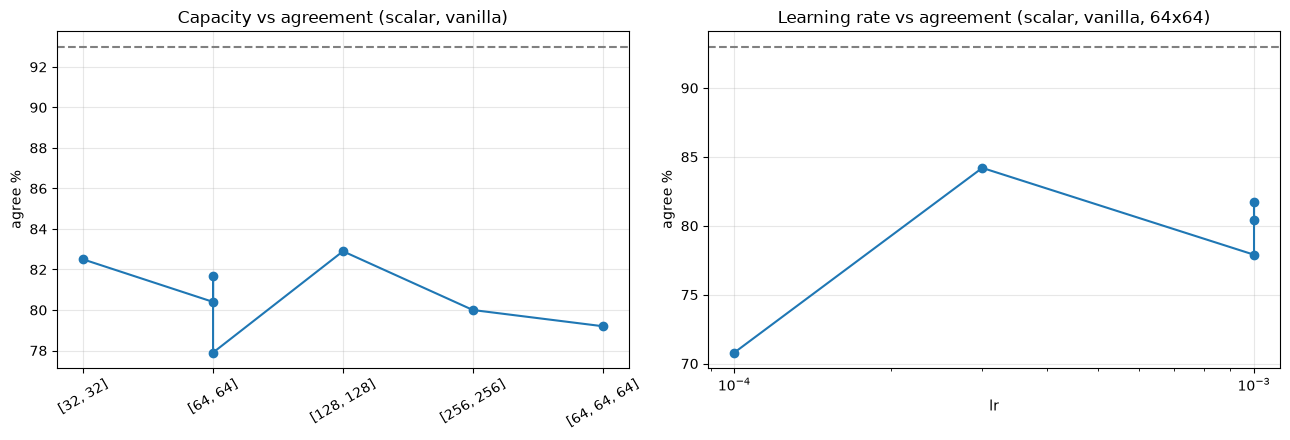

In [6]:
base = tbl[(tbl.enc=="scalar") & (tbl["double"]==False) & (tbl.ES==False) & (tbl.seed==42)]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
# capacity: net size vs agreement (lr default 0.001)
cap = base[base.lr==0.001].copy()
order = {"[32, 32]":0,"[64, 64]":1,"[128, 128]":2,"[256, 256]":3,"[64, 64, 64]":4}
cap = cap[cap.hidden.isin(order)].sort_values("hidden", key=lambda s: s.map(order))
ax[0].plot(cap.hidden, cap["agree%"], "o-")
ax[0].axhline(93, ls="--", c="gray"); ax[0].set_title("Capacity vs agreement (scalar, vanilla)")
ax[0].set_ylabel("agree %"); ax[0].tick_params(axis="x", rotation=30); ax[0].grid(alpha=.3)
# learning rate vs agreement (hidden 64x64)
lrc = base[base.hidden=="[64, 64]"].sort_values("lr")
ax[1].plot(lrc.lr, lrc["agree%"], "o-"); ax[1].set_xscale("log")
ax[1].axhline(93, ls="--", c="gray"); ax[1].set_title("Learning rate vs agreement (scalar, vanilla, 64x64)")
ax[1].set_xlabel("lr"); ax[1].set_ylabel("agree %"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Learning curves — agreement over training (selected runs)

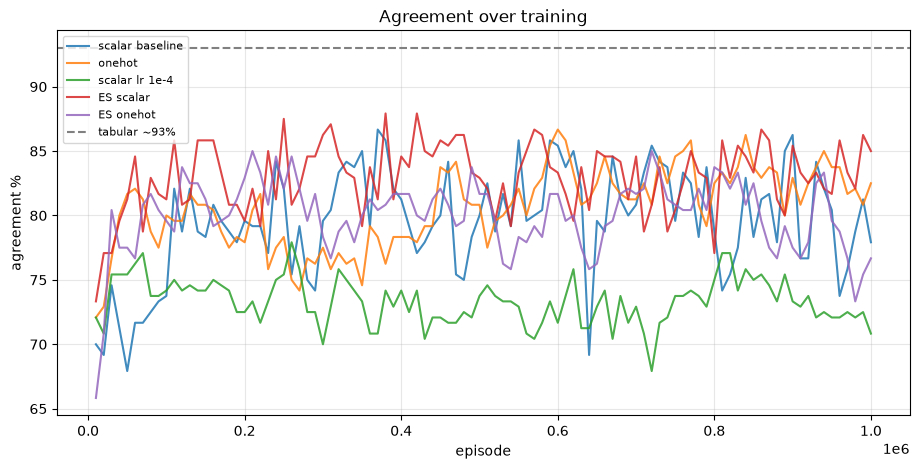

In [7]:
def find(**kw):
    for r in DQN:
        c = r["config"]
        if all(c.get(k) == v for k, v in kw.items()):
            return r
    return None

def curve(r):
    lc = r.get("learning_curve", [])
    xs = [p["episode"] for p in lc if p.get("agreement") is not None]
    ys = [p["agreement"]*100 for p in lc if p.get("agreement") is not None]
    return xs, ys

picks = [
    ("scalar baseline", dict(encoding="scalar", double_dqn=False, exploring_starts=False, seed=42, lr=0.001, hidden=[64,64])),
    ("onehot",          dict(encoding="onehot", double_dqn=False, exploring_starts=False, seed=42, lr=0.001, hidden=[64,64])),
    ("scalar lr 1e-4",  dict(encoding="scalar", lr=0.0001, exploring_starts=False, double_dqn=False, seed=42)),
    ("ES scalar",       dict(encoding="scalar", exploring_starts=True, double_dqn=False, lr=0.001, seed=42)),
    ("ES onehot",       dict(encoding="onehot", exploring_starts=True, double_dqn=False, lr=0.001, seed=42)),
]
plt.figure(figsize=(11, 5))
for label, kw in picks:
    r = find(**kw)
    if r:
        xs, ys = curve(r)
        if xs: plt.plot(xs, ys, label=label, alpha=.85)
plt.axhline(93, ls="--", c="gray", label="tabular ~93%")
plt.xlabel("episode"); plt.ylabel("agreement %"); plt.title("Agreement over training")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()

## 6. Q1 — was the over-valued action over- or under-*tested*?

Uses `sample_counts` (experience counts per (cell, action)) from an instrumented natural-play run.
**The pivotal read:** in the over-double cells, is `double` sampled *more* than `stand` (yet still
wrong -> representation, ES won't help) or *less* (-> coverage, ES fixes it)?

In [8]:
inst = find(encoding="onehot", double_dqn=False, exploring_starts=False, seed=42, lr=0.001, hidden=[64,64])
if inst is None or not inst.get("sample_counts"):
    print("no instrumented onehot baseline yet (need a run carrying sample_counts).")
else:
    sc = {(s["player_value"], s["is_soft"], s["dealer_upcard"], s["action"]): s["count"]
          for s in inst["sample_counts"]}
    over = [c for c in inst["diff"]["cells"]
            if c["category"]=="genuine_disagreement" and c["agent_action"]=="double" and c["basic_action"]!="double"]
    print(f"instrumented run {inst['_id'][-7:]}  | over-double cells: {len(over)}\n")
    tot_d = tot_s = 0
    for c in over:
        k = (c["player_value"], c["is_soft"], c["dealer_upcard"])
        d  = sc.get((*k, "double"), 0); s_ = sc.get((*k, "stand"), 0); h = sc.get((*k, "hit"), 0)
        tot_d += d; tot_s += s_
        kind = "soft" if c["is_soft"] else "hard"
        flag = "double OVER-sampled" if d > s_ else "double UNDER-sampled"
        print(f"  {kind}{c['player_value']} v{c['dealer_upcard']}: double={d:,}  stand={s_:,}  hit={h:,}   -> {flag}")
    print(f"\nAGGREGATE over over-double cells: double={tot_d:,}  stand={tot_s:,}")
    print("verdict:", "double WELL-sampled yet wrong -> REPRESENTATION (ES won't fix)" if tot_d >= tot_s
          else "double UNDER-sampled -> COVERAGE (ES should fix)")

instrumented run de8e6b8  | over-double cells: 15

  hard8 v2: double=262  stand=194  hit=1,953   -> double OVER-sampled
  hard8 v6: double=1,176  stand=219  hit=980   -> double OVER-sampled
  hard9 v2: double=1,256  stand=152  hit=1,650   -> double OVER-sampled
  hard9 v7: double=1,296  stand=150  hit=1,580   -> double OVER-sampled
  hard11 v11: double=854  stand=163  hit=1,952   -> double OVER-sampled
  soft13 v3: double=269  stand=77  hit=619   -> double OVER-sampled
  soft13 v4: double=295  stand=49  hit=623   -> double OVER-sampled
  soft14 v7: double=142  stand=65  hit=759   -> double OVER-sampled
  soft15 v3: double=337  stand=83  hit=655   -> double OVER-sampled
  soft16 v3: double=260  stand=166  hit=705   -> double OVER-sampled
  soft19 v5: double=467  stand=816  hit=88   -> double UNDER-sampled
  soft19 v6: double=398  stand=700  hit=69   -> double UNDER-sampled
  soft20 v3: double=367  stand=928  hit=69   -> double UNDER-sampled
  soft20 v5: double=439  stand=739  hit=86   

## 7. Q2 — how did the Q-values evolve? (probe-cell trajectories)

Per-checkpoint `probe_q` lets us watch Q(hit/stand/double) over training: does Q(double) spike
*late* (a "lucky double" that flips greedy) or sit inflated *from the start* (extrapolation)?

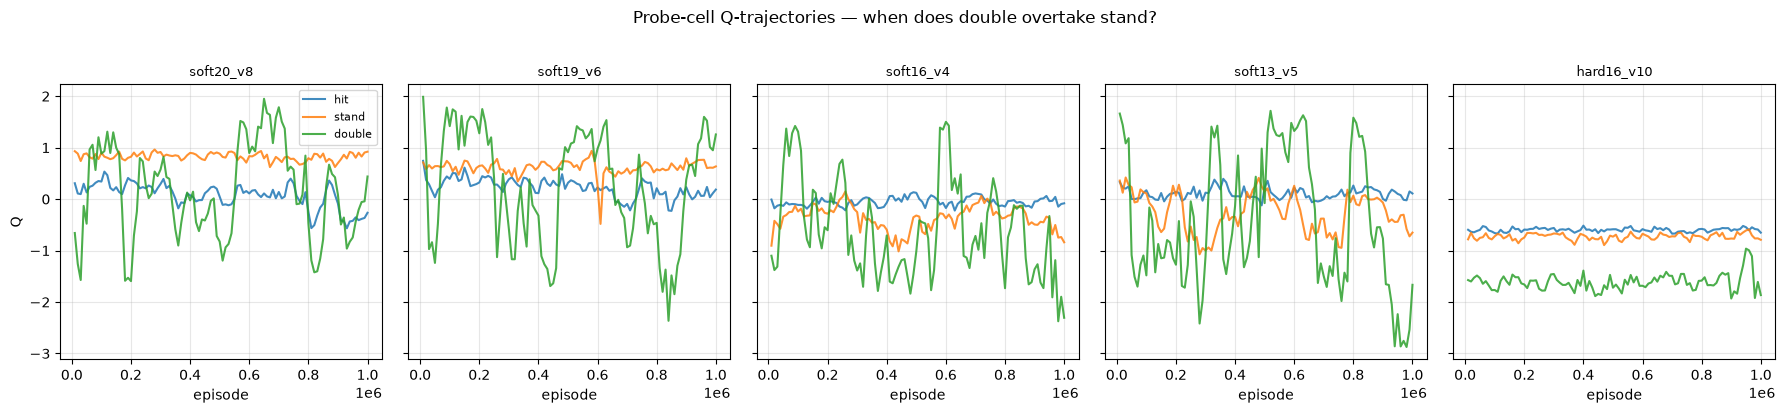

In [9]:
inst = find(encoding="onehot", double_dqn=False, exploring_starts=False, seed=42, lr=0.001, hidden=[64,64])
lc = inst.get("learning_curve", []) if inst else []
pts = [p for p in lc if "probe_q" in p]
if not pts:
    print("no probe_q trajectory yet (need an instrumented run).")
else:
    cellnames = list(pts[-1]["probe_q"].keys())
    eps = [p["episode"] for p in pts]
    fig, axes = plt.subplots(1, len(cellnames), figsize=(3.6*len(cellnames), 4), sharey=True)
    if len(cellnames) == 1: axes = [axes]
    for ax, cell in zip(axes, cellnames):
        for act in ("hit", "stand", "double"):
            ys = [p["probe_q"][cell].get(act) for p in pts]
            ax.plot(eps, ys, label=act, alpha=.85)
        ax.set_title(cell, fontsize=9); ax.set_xlabel("episode"); ax.grid(alpha=.3)
    axes[0].set_ylabel("Q"); axes[0].legend(fontsize=8)
    plt.suptitle("Probe-cell Q-trajectories — when does double overtake stand?", y=1.02)
    plt.tight_layout(); plt.show()

## 8. Coverage signature — are disagreements in rare cells? (rarity)

AGREE median visits 18,896 | GENUINE median 6,797 (~2.8x rarer)


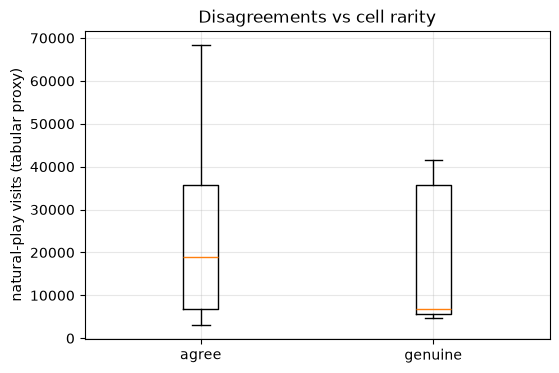

In [10]:
def tabular_visits():
    for r in RECORDS:
        if not is_dqn(r) and "qtable" in r:
            vis = {}
            for row_ in r["qtable"]:
                k = (row_["player_value"], bool(row_["is_soft"]), row_["dealer_upcard"])
                vis[k] = vis.get(k, 0) + int(row_["n"])
            return vis
    return {}

VIS = tabular_visits()
inst = find(encoding="onehot", double_dqn=False, exploring_starts=False, seed=42, lr=0.001, hidden=[64,64])
if inst and VIS:
    agree, gen = [], []
    for c in inst["diff"]["cells"]:
        v = VIS.get((c["player_value"], c["is_soft"], c["dealer_upcard"]), 0)
        (gen if c["category"]=="genuine_disagreement" else agree).append(v)
    print(f"AGREE median visits {int(st.median(agree)):,} | GENUINE median {int(st.median(gen)):,} "
          f"(~{st.median(agree)/max(st.median(gen),1):.1f}x rarer)")
    plt.figure(figsize=(6,4)); plt.boxplot([agree, gen], tick_labels=["agree","genuine"], showfliers=False)
    plt.ylabel("natural-play visits (tabular proxy)"); plt.title("Disagreements vs cell rarity"); plt.grid(alpha=.3); plt.show()
else:
    print("need a DQN run + a tabular run with qtable")

## 9. Exploring-starts capstone — did forced coverage fix it?

Compare ES vs its natural counterpart: agreement, over/under-double counts, and (if instrumented)
the soft-20 double Q — did it fall toward the true ~+0.25?

In [11]:
def od(r):
    gen = [c for c in r["diff"]["cells"] if c["category"]=="genuine_disagreement"]
    return (round(r["diff"]["agreement_unweighted"]*100,1), len(gen),
            sum(1 for c in gen if c["agent_action"]=="double" and c["basic_action"]!="double"),
            sum(1 for c in gen if c["basic_action"]=="double" and c["agent_action"]!="double"))

for enc in ("scalar", "onehot"):
    nat = find(encoding=enc, exploring_starts=False, double_dqn=False, seed=42, lr=0.001, hidden=[64,64])
    es  = find(encoding=enc, exploring_starts=True,  double_dqn=False, seed=42, lr=0.001)
    print(f"--- {enc} ---")
    for lbl, r in [("natural", nat), ("exploring-starts", es)]:
        if r:
            a, g, o, u = od(r)
            print(f"  {lbl:16}: agree {a}%  genuine {g}  over_dbl {o}  under_dbl {u}")
    if es:
        pts = [p for p in es.get("learning_curve", []) if "probe_q" in p]
        if pts:
            print(f"  ES final probe Q: {pts[-1]['probe_q']}")
    print()

--- scalar ---
  natural         : agree 77.9%  genuine 51  over_dbl 36  under_dbl 4
  exploring-starts: agree 85.0%  genuine 34  over_dbl 24  under_dbl 0
  ES final probe Q: {'soft20_v8': {'hit': 0.211, 'stand': 0.824, 'double': 0.519}, 'soft19_v6': {'hit': 0.307, 'stand': 0.667, 'double': 1.164}, 'soft16_v4': {'hit': 0.07, 'stand': -0.274, 'double': 0.911}, 'soft13_v5': {'hit': 0.149, 'stand': -0.236, 'double': 0.998}, 'hard16_v10': {'hit': -0.63, 'stand': -0.807, 'double': -1.706}}

--- onehot ---
  natural         : agree 82.5%  genuine 42  over_dbl 15  under_dbl 14
  exploring-starts: agree 76.7%  genuine 52  over_dbl 30  under_dbl 8
  ES final probe Q: {'soft20_v8': {'hit': 0.232, 'stand': 0.865, 'double': 1.33}, 'soft19_v6': {'hit': 0.254, 'stand': 0.43, 'double': 1.39}, 'soft16_v4': {'hit': 0.046, 'stand': -0.357, 'double': 1.054}, 'soft13_v5': {'hit': 0.209, 'stand': -0.144, 'double': 1.344}, 'hard16_v10': {'hit': -0.642, 'stand': -0.625, 'double': -1.756}}



## Findings (fill in after reading)

- Best config (by mean agreement across seeds): _____
- Seed wobble (median std): _____ pts -> the floor for "real" differences
- Capacity: did bigger nets help? _____   Learning rate: did lower lr calm the wobble? _____
- Q1 (sample_counts): in over-double cells, double was OVER / UNDER sampled -> coverage vs representation: _____
- Q2 (probe_q): Q(double) inflated early (extrapolation) or spiked late (lucky double)? _____
- Exploring starts: did forced coverage collapse the rare-cell errors and pull double Q to truth? _____
- Verdict on the residual: coverage (fixable) vs boundary-precision/representation floor: _____